In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd
import contextily as ctx

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone, BaseEstimator, TransformerMixin

RANDOM_SEED = 42

## EDA

In [2]:
df = pd.read_csv("data/housing.csv")

print(df.head())

print("Missing values per column")
print(df.isna().sum())

display(df.describe())

target_column_name = "median_house_value"
feature_column_name = [col for col in df.columns if col != target_column_name]
print(f"Features: {feature_column_name}")
print(f"Shape {df.shape}")
print(f"Datatyper {df.dtypes}")

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
Missing values per column
longitude               0
latitude               

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']
Shape (20640, 10)
Datatyper longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object


# Saknade värden
Med klassen nedan hanteras saknade värden genom SimpleImputer, samt plockar bort bas-columnerna 'total_bedrooms' & 'households' för att minska brus.
Klassen används senare i pipeline.

In [3]:
class BedroomRatioTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, strategy="median"):
        self.strategy = strategy

    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.imputer_ = SimpleImputer(strategy=self.strategy)
        self.imputer_.fit(X[["total_bedrooms"]])
        return self

    def transform(self, X):
        X = X.copy()
        X["total_bedrooms"] = self.imputer_.transform(X[["total_bedrooms"]])
        X["bedrooms_per_household"] = X["total_bedrooms"] / X["households"]
        return X.drop(columns=["total_bedrooms", "households"])

<Axes: >

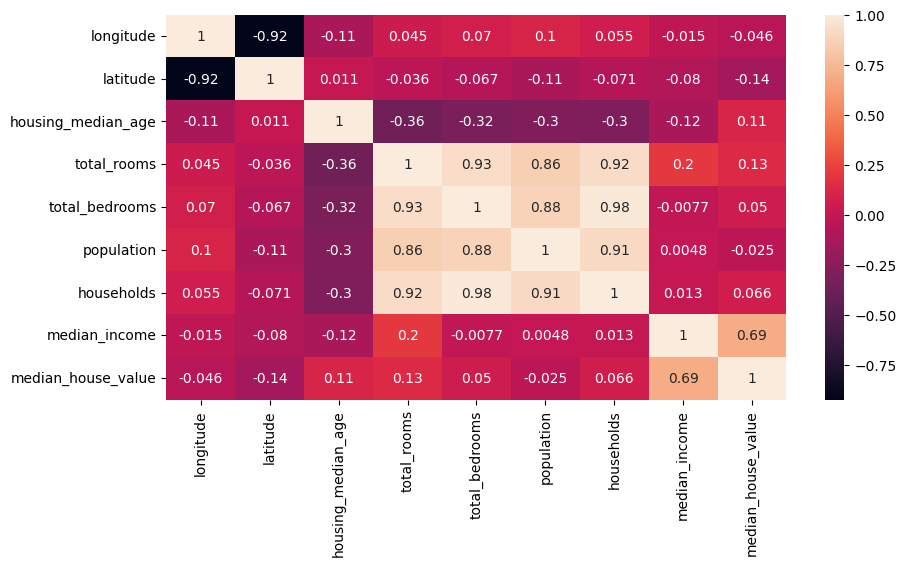

In [4]:
correlation_matrix = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(correlation_matrix, annot=True, ax=ax)

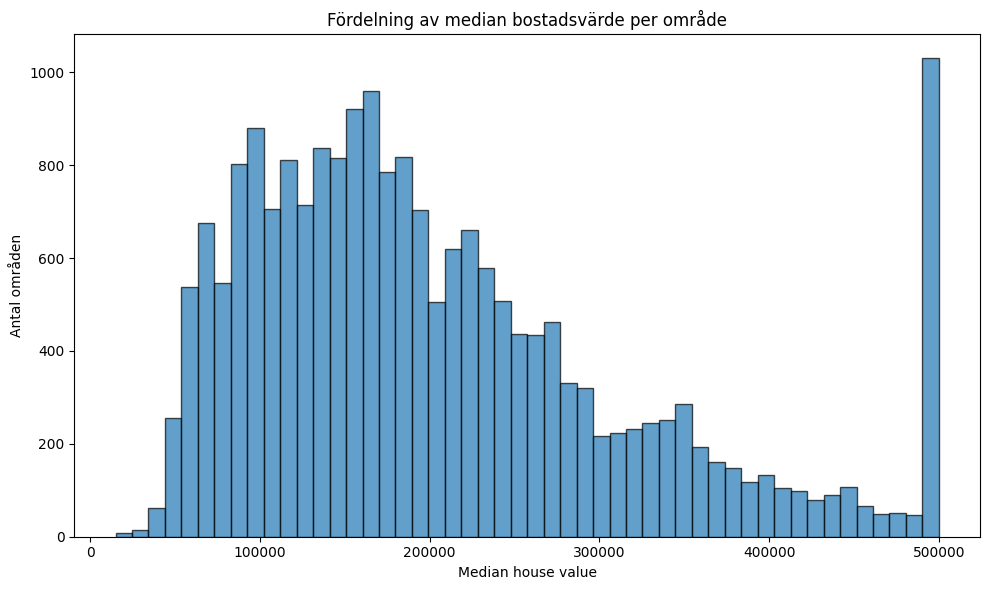

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df["median_house_value"], bins=50, edgecolor="black", alpha=0.7)
ax.set_xlabel("Median house value")
ax.set_ylabel("Antal områden")
ax.set_title("Fördelning av median bostadsvärde per område")
plt.tight_layout()
plt.show()

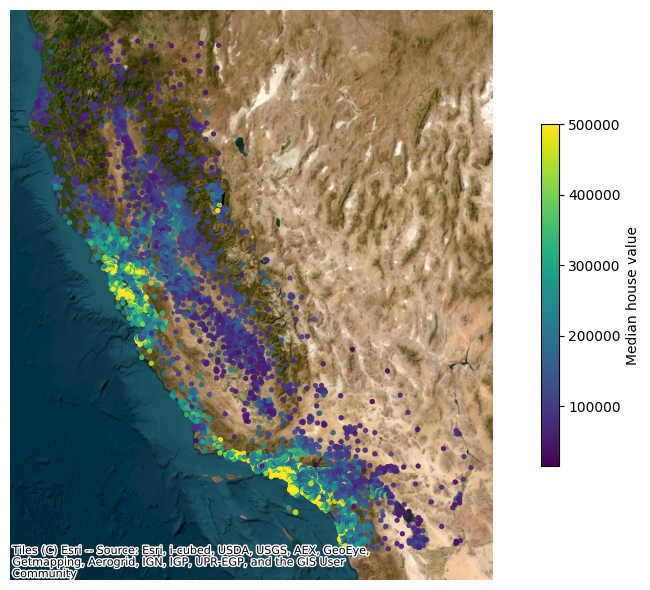

In [6]:
gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326",
)

gdf = gdf.to_crs(3857)
ctx.set_cache_dir("cache/contextily")

fig, ax = plt.subplots(figsize=(10, 6))
gdf.plot(
    ax=ax,
    column="median_house_value",
    cmap="viridis",
    markersize=8,
    alpha=0.85,
    legend=True,
    legend_kwds={"label": "Median house value", "shrink": 0.6},
)
ctx.add_basemap(ax, crs=gdf.crs, source=ctx.providers.Esri.WorldImagery)
ax.set_axis_off()
plt.tight_layout()
plt.show()

Kartan ovan ger en tydlig bild av sambandet mellan närheten till havet och priset hänger ihop

# Train/test split

In [7]:
X = df[feature_column_name]
y = df[target_column_name]

y_bins = pd.qcut(y, q=10, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y_bins,
    random_state=RANDOM_SEED
)

print("Train data:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print(X_train.head())

Train data: (16512, 9) (16512,)
Test shape: (4128, 9) (4128,)
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
12344    -116.50     33.82                16.0        343.0            85.0   
8489     -118.29     33.91                28.0       1501.0           446.0   
4170     -118.21     34.10                47.0       5077.0          1271.0   
8737     -118.31     33.82                39.0       2198.0           425.0   
14440    -117.24     32.80                29.0       3376.0           882.0   

       population  households  median_income ocean_proximity  
12344        29.0        14.0         2.1042          INLAND  
8489       1028.0       418.0         2.3043       <1H OCEAN  
4170       3348.0      1106.0         3.0377       <1H OCEAN  
8737       1160.0       436.0         4.1406       <1H OCEAN  
14440      1513.0       843.0         3.1010      NEAR OCEAN  


# Pipeline

In [8]:
numeric_features = [
    "longitude", "latitude", "housing_median_age",
    "total_rooms", "population", "median_income",
    "bedrooms_per_household"
]

categorical_features = ["ocean_proximity"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

full_preprocessor = Pipeline(
    steps=[
        ("bedroom_ratio", BedroomRatioTransformer(strategy="median")),
        ("column_transformer", preprocessor)
    ]
)

# Modeller

In [9]:
models = {
    "Baseline (dummy median)": Pipeline([
    ("preprocessor", clone(full_preprocessor)),
    ("model", DummyRegressor(strategy="median")),
]),

    "Ridge": Pipeline([
    ("preprocessor", clone(full_preprocessor)),
    ("model", Ridge(alpha=1.0))
]),

    "Random Forest": Pipeline([
    ("preprocessor", clone(full_preprocessor)),
    ("model", RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)),
])
}

# Cross-validation

In [10]:
cv = KFold(n_splits=5, random_state=RANDOM_SEED, shuffle=True)

cv_rows = []
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

for name, pipe in models.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "stage": "CV (5-fold)",
        "model": name,
        "RMSE": -scores["test_rmse"].mean(),
        "MAE": -scores["test_mae"].mean(),
        "R2": scores["test_r2"].mean()
    })
    
df_results = pd.DataFrame(cv_rows)
display(df_results)

,stage,model,RMSE,MAE,R2
0,CV (5-fold),Baseline (dummy median),118683.617227,88412.835617,-0.055704
1,CV (5-fold),Ridge,70229.374673,51489.186506,0.630290
2,CV (5-fold),Random Forest,49730.063972,32627.161352,0.814604


Random forest valdes eftersom den gav lägst medel-RMSE i CV jämfört med de andra två modellerna.

# Optimizering/tuning

In [11]:
chosen_model = "Random Forest"
print("Tuning:", chosen_model)

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 20, 30],
    "model__min_samples_leaf": [1, 4, 8],
}

grid = GridSearchCV(
    estimator=models[chosen_model],
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameter:", grid.best_params_)
print("Best CV-RMSE:", -grid.best_score_)

tuning_row = pd.DataFrame([{
    "stage": "GridSearchCV",
    "model": "Random Forest (tuned)",
    "RMSE": -grid.best_score_,
    "MAE": pd.NA,
    "R2": pd.NA
}])

Tuning: Random Forest
Best parameter: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Best CV-RMSE: 49546.46655317572


Optimering genom GridSearchCV på träningsdatan med 5-fold cross-validation och med RMSE som mätvärde (samma som användes för att välja model). Provade olika värden för n_estimators, max_depth och min_sample_leaf för att hitta de bästa parametrarna.

# Validering test-data

In [12]:
tuned_model = grid.best_estimator_

y_pred_test = tuned_model.predict(X_test)

rmse_test = root_mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"Test RMSE: {rmse_test:,.0f}")
print(f"Test MAE:  {mae_test:,.0f}")
print(f"Test R2:   {r2_test:.2f}")

test_row = pd.DataFrame([{
    "stage": "Test",
    "model": "Random Forest (tuned)",
    "RMSE": rmse_test,
    "MAE": mae_test,
    "R2": r2_test,
}])

Test RMSE: 49,555
Test MAE:  32,302
Test R2:   0.81


In [13]:
full_table = pd.concat([df_results, tuning_row, test_row])
display(full_table)

,stage,model,RMSE,MAE,R2
0,CV (5-fold),Baseline (dummy median),118683.617227,88412.835617,-0.055704
1,CV (5-fold),Ridge,70229.374673,51489.186506,0.63029
2,CV (5-fold),Random Forest,49730.063972,32627.161352,0.814604
0,GridSearchCV,Random Forest (tuned),49546.466553,<NA>,<NA>
0,Test,Random Forest (tuned),49554.846068,32302.399444,0.813918


# Utvärdering & rekommendation

RMSE användes som huvudmått eftersom det straffar stora prediktionsfel, och MAE som komplement eftersom det ger ett tydligt genomsnittligt fel.

Som slutlig modell rekommenderas den tunerade Random Forest-pipelinen: den gav lägst RMSE i korsvalidering och generaliserade väl till testset (RMSE …, MAE …). Ridge är snabbare och mer tolkbar men gav sämre prediktion. Baseline används bara som referens.

Modellen kan användas för grova värderingar men bör inte ersätta individuella fastighetsvärderingar.